<a href="https://colab.research.google.com/github/Spatel1309/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. Adding a penalty to mean squared error discourages the model from using large coefficients, which often arise when the model is overfitting the training model. By increasing the penalty of large parameter values, the model is pushed to find solutions that are accurate on the training data and also simpler and more stable. This leads to smoother relationships between inputs and outputs, making predictions less sensitive to small changes in the data.

2. Regularization provides a direct way to explore the bias–variance trade-off by introducing a tuning parameter that controls how strongly we penalize large coefficients. When regularization is zero, there is no penalty, so the model focuses entirely on minimizing training error, resulting in low bias but high variance. As the regularization increases, the penalty forces coefficients to shrink, making the model simpler and more stable, which reduces variance but increases bias.

3. The key difference between LASSO and Ridge regression is how they penalize the size of the coefficients. Ridge regression uses an L2 penalty (squared values of coefficients), while LASSO uses an L1 penalty (absolute values of coefficients). Because Ridge squares the coefficients, it shrinks all coefficients smoothly toward zero, but almost never makes them exactly zero. This means Ridge keeps all predictors in the model, just with smaller magnitudes. In contrast, LASSO’s absolute value penalty can force some coefficients to be exactly zero, effectively removing those variables from the model. So Ridge regression keeps the variables, but lowers their effect. LASSO simplifies the model by eliminating variables and keeping the rest.

4. We typically scale variables using methods like min-max scaling, rescaling to the range from 0 (smallest) to 1 (largest). This ensures that all variables are on a comparable scale, since different features may be measured in very different units (e.g., age vs. height). Regularization methods penalize coefficients based on their size, so without scaling, variables with larger units could be unfairly penalized more heavily. By scaling the variables, we ensure that the penalty is applied consistently across all predictors. It is also easier to tranform the data and then compare the untransformed data later.

5. The penalty α  is typically selected using cross-validation. We first pick a grid of α values. Then for each value, we use k-fold cross-validation and pick a coefficient to minimize MSE(b) + α|b| or MSE(b) + αb^2. Then we evaluate the MSE(b) and save the estimates. Then pick the average value for each α and then select the value that minimizes this error across the grid

6. No, you do not include the penalty term when evaluating the cross-validated MSE. This is because cross-validation is meant to estimate true out-of-sample prediction error. We care about prediction accuracy—not the size of the coefficients. Including the penalty in the evaluation would bias the error measure and not reflect how well the model performs on new data.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [ ]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv("cars_hw (1).csv")

df["Age"] = 2026 - df["Make_Year"]

X = df[["Mileage_Run", "Age"]]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
poly_names = poly.get_feature_names_out()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [ ]:
from sklearn.linear_model import LinearRegression

y = df["Price"]

model = LinearRegression()
model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "feature": poly_names,
    "coefficient": model.coef_
})

coef_df[coef_df["feature"] == "Mileage_Run Age"]

The sign of the interaction between Mileage_Run and Age is negative, indicating that the combined effect of higher mileage and greater age reduces the price more strongly than either variable individually.

In [ ]:
from sklearn.linear_model import LassoCV
import numpy as np

alphas = np.logspace(1,3,20)

model = LassoCV(cv=20,
                alphas=alphas,
                random_state=100)
model = model.fit(X_scaled, y)

model_coef = pd.DataFrame({
    "feature": poly_names,
    "coefficient": model.coef_
})
model_coef[model_coef["feature"] == "Mileage_Run Age"]

In [ ]:
import matplotlib.pyplot as plt

mse_mean = model.mse_path_.mean(axis=1)

plt.figure()
plt.plot(model.alphas_, mse_mean)
plt.xscale("log")


plt.axvline(model.alpha_, linestyle="--")

plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("CV MSE vs alpha (LASSO)")
plt.show()

print(f'Optimal cost hyperparameter: {model.alpha_}')

In [ ]:
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure()

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient values")
plt.title("LASSO Coefficient Paths")

plt.axvline(model.alpha_, linestyle="--")

plt.show()

In [ ]:
best_coefs = model_coef["coefficient"]

num_zero = np.sum(best_coefs == 0)
total = len(best_coefs)

print("Zero:", num_zero)
print("Total:", total)
print("Proportion:", num_zero / total)

Although some coefficients appear to be zero in the plot, they are actually just very close to zero rather than exactly zero. All coefficients remain nonzero, so all features are technically selected, and the proportion of coefficients set to zero is 0.

Compared to linear regression, the LASSO coefficients decrease in magnitude due to the regularization penalty, and no coefficients increase in magnitude. Additionally, the signs of the coefficients remain the same, as LASSO primarily shrinks coefficients toward zero rather than reversing their direction.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [ ]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import numpy as np

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

v = df[["age", "ejection_fraction", "serum_creatinine"]]

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(v)

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

dv = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

poly_cat = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_cat_interact = poly_cat.fit_transform(dv)


X_final = np.hstack([X_cont_scaled, X_cat_interact])

X_final

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

y = df["DEATH_EVENT"]

model = LinearRegression()
model.fit(X_final, y)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_
})

coef_df

After running the linear regression, several coefficients appear counterintuitive in sign, such as age having a positive coefficient while age² has a negative coefficient, and ejection_fraction having a negative coefficient, while ejection_fraction² a positive coefficient. This occurs because the model includes higher-order polynomial terms and interactions, so the effect of each variable is not captured by a single coefficient. Instead, the overall effect depends on combinations of terms. These higher-order and interaction terms resolve the apparent contradiction by modeling how the effect of a variable changes across different values and in combination with other variables.

In [ ]:
from sklearn.linear_model import LassoCV
import numpy as np
import pandas as pd

alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)

lasso.fit(X_final, y)

alpha_star = lasso.alpha_

print("Best alpha:", alpha_star)

lasso_coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lasso.coef_
})

lasso_coef_df

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mse_mean = np.mean(lasso.mse_path_, axis=1)

plt.figure()
plt.plot(lasso.alphas_, mse_mean)

plt.xscale("log")

plt.axvline(lasso.alpha_, linestyle="--")

plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("CV MSE vs alpha (LASSO)")
plt.show()

In [ ]:
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt
import numpy as np

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_final, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure()

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient values")
plt.title("LASSO Coefficient Paths")

plt.axvline(alpha_star, linestyle="--", color="black")

plt.show()

In [ ]:
best_coefs = lasso_coef_df["coefficient"]

num_zero = np.sum(best_coefs == 0)
total = len(best_coefs)

print("Zero:", num_zero)
print("Total:", total)
print("Proportion:", num_zero / total)

In [ ]:
selected_features = lasso_coef_df[np.abs(lasso_coef_df["coefficient"]) > 0]

selected_features[["feature", "coefficient"]]

LASSO selects a subset of features with nonzero coefficients, listed above. It set 21 out of 33 coefficients (approximately 63.6%) to zero. Compared to linear regression, LASSO reduces coefficient magnitudes and does not increase them, with signs largely preserved. The LASSO model produces more interpretable and stable sign patterns by eliminating noisy features. From a bias–variance perspective, LASSO introduces some bias through regularization but substantially reduces variance, leading to improved generalization and a simpler model.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

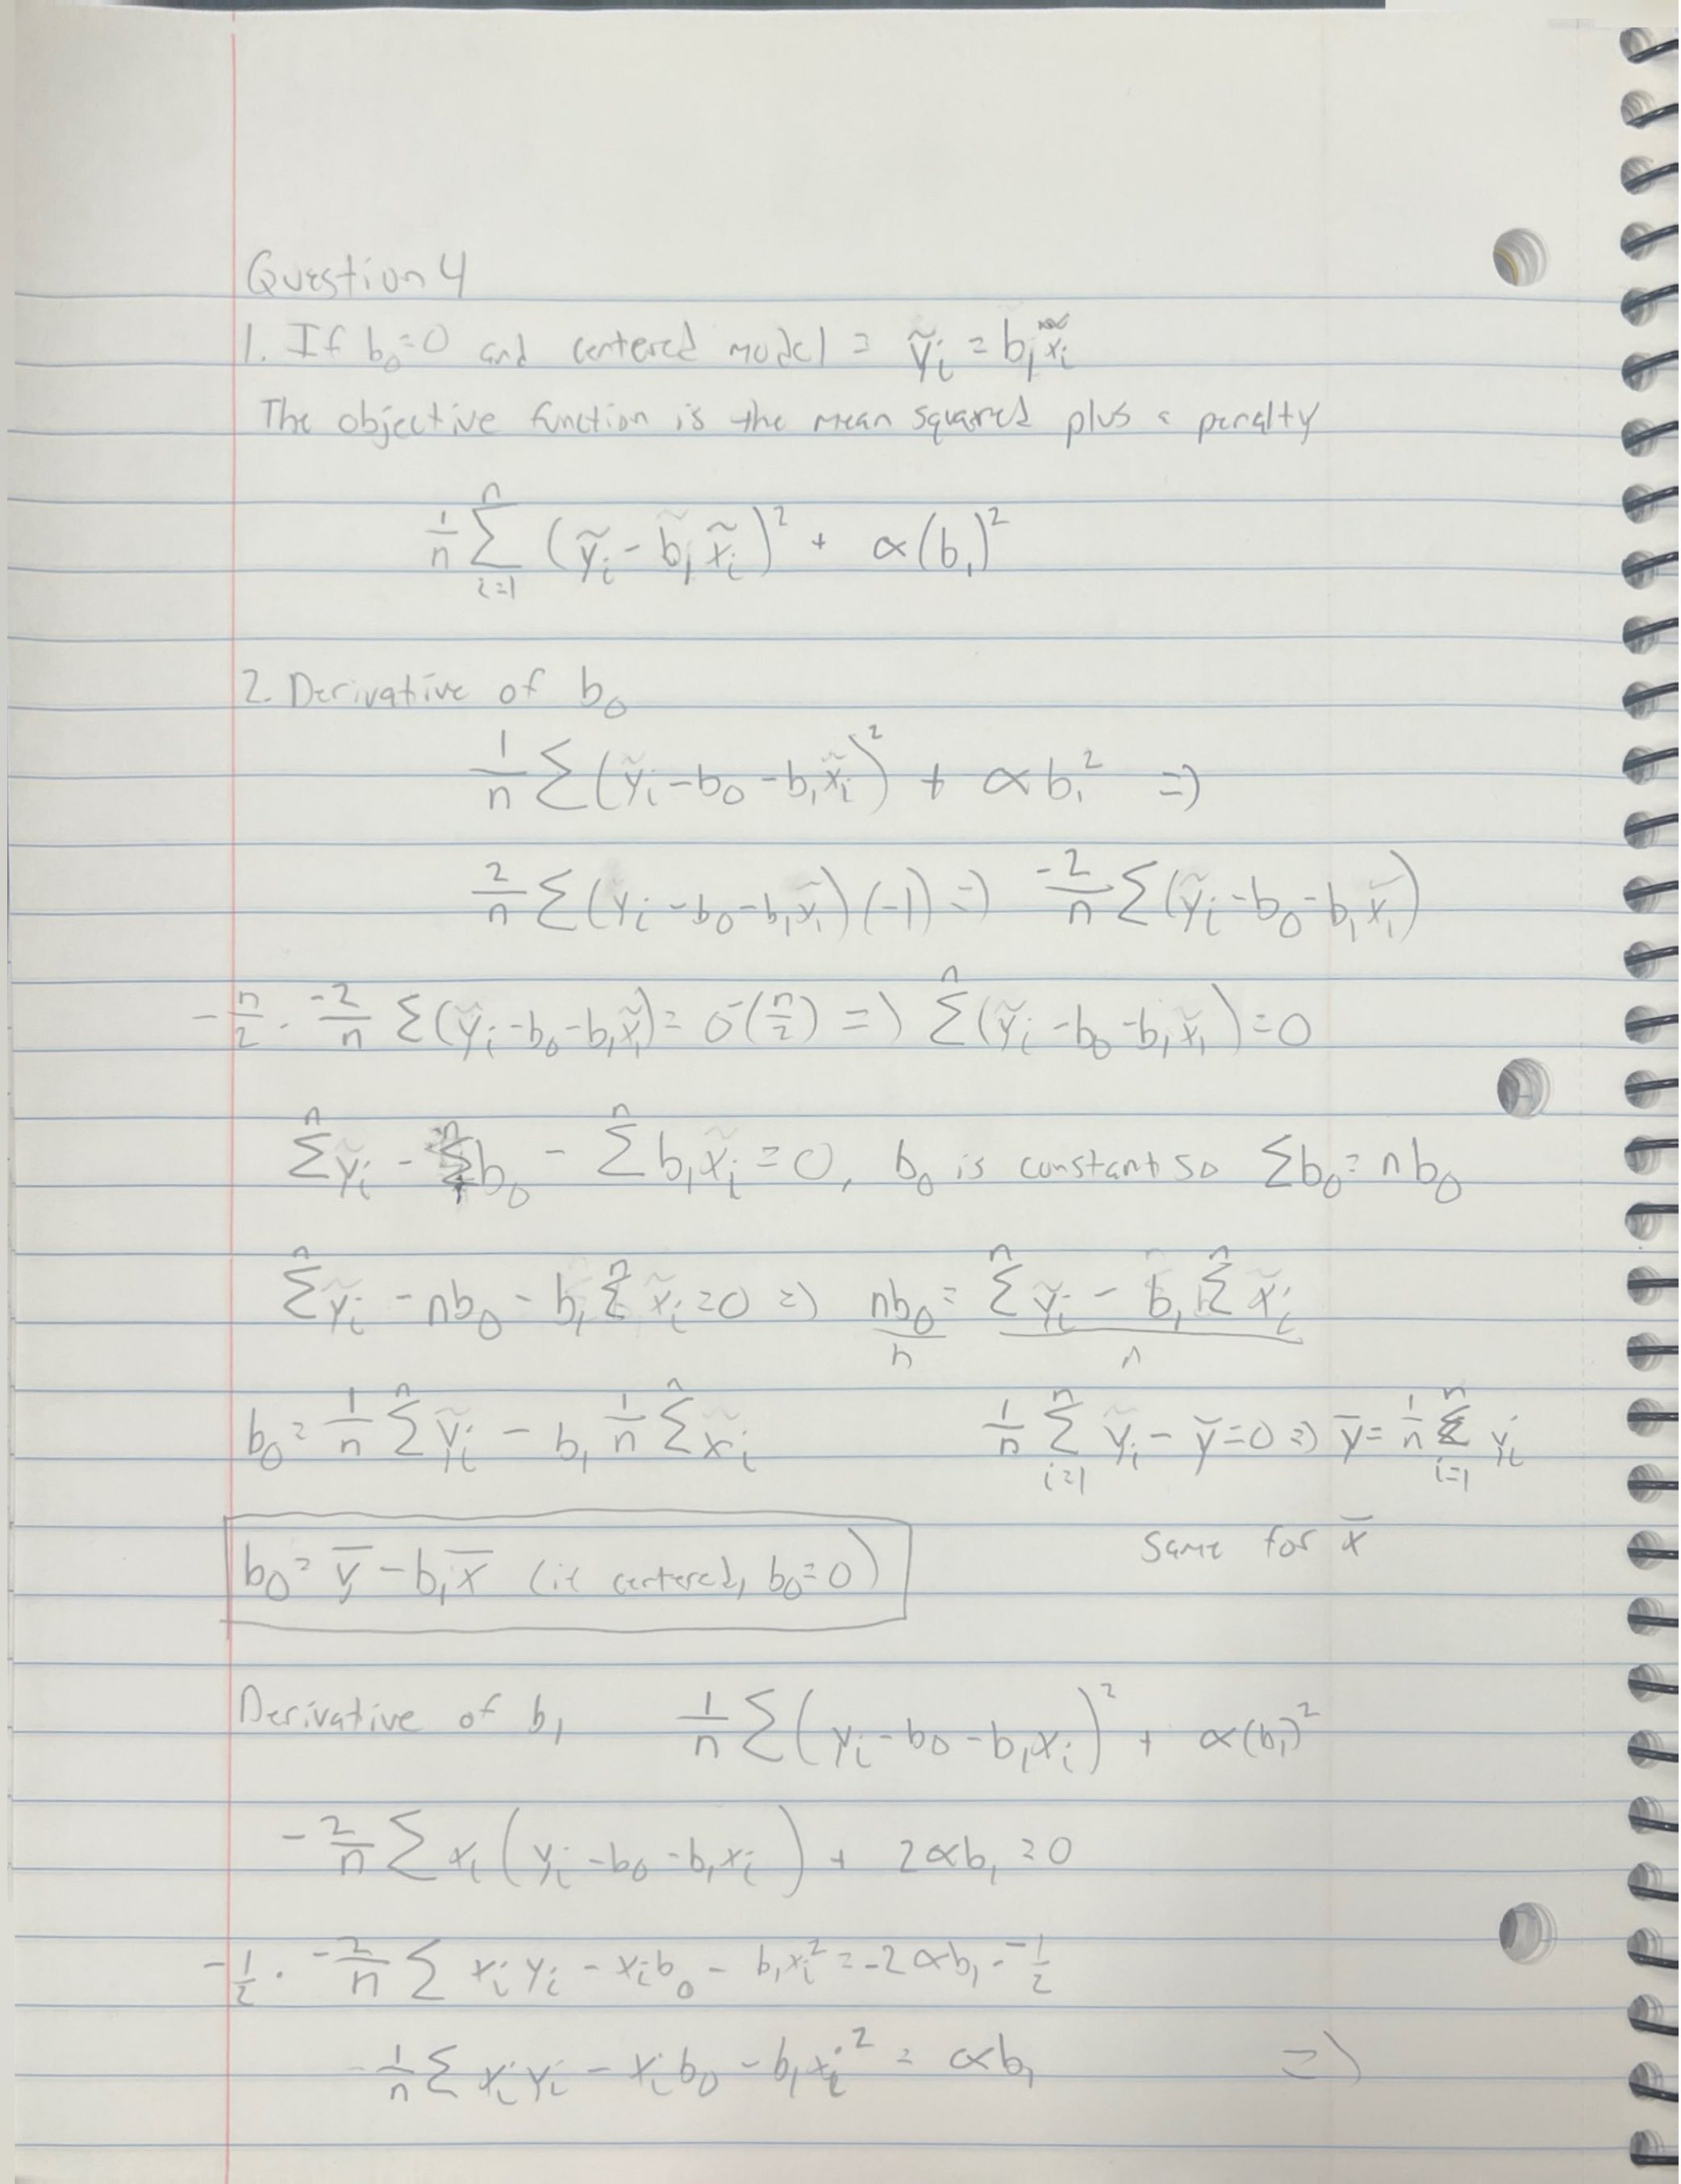

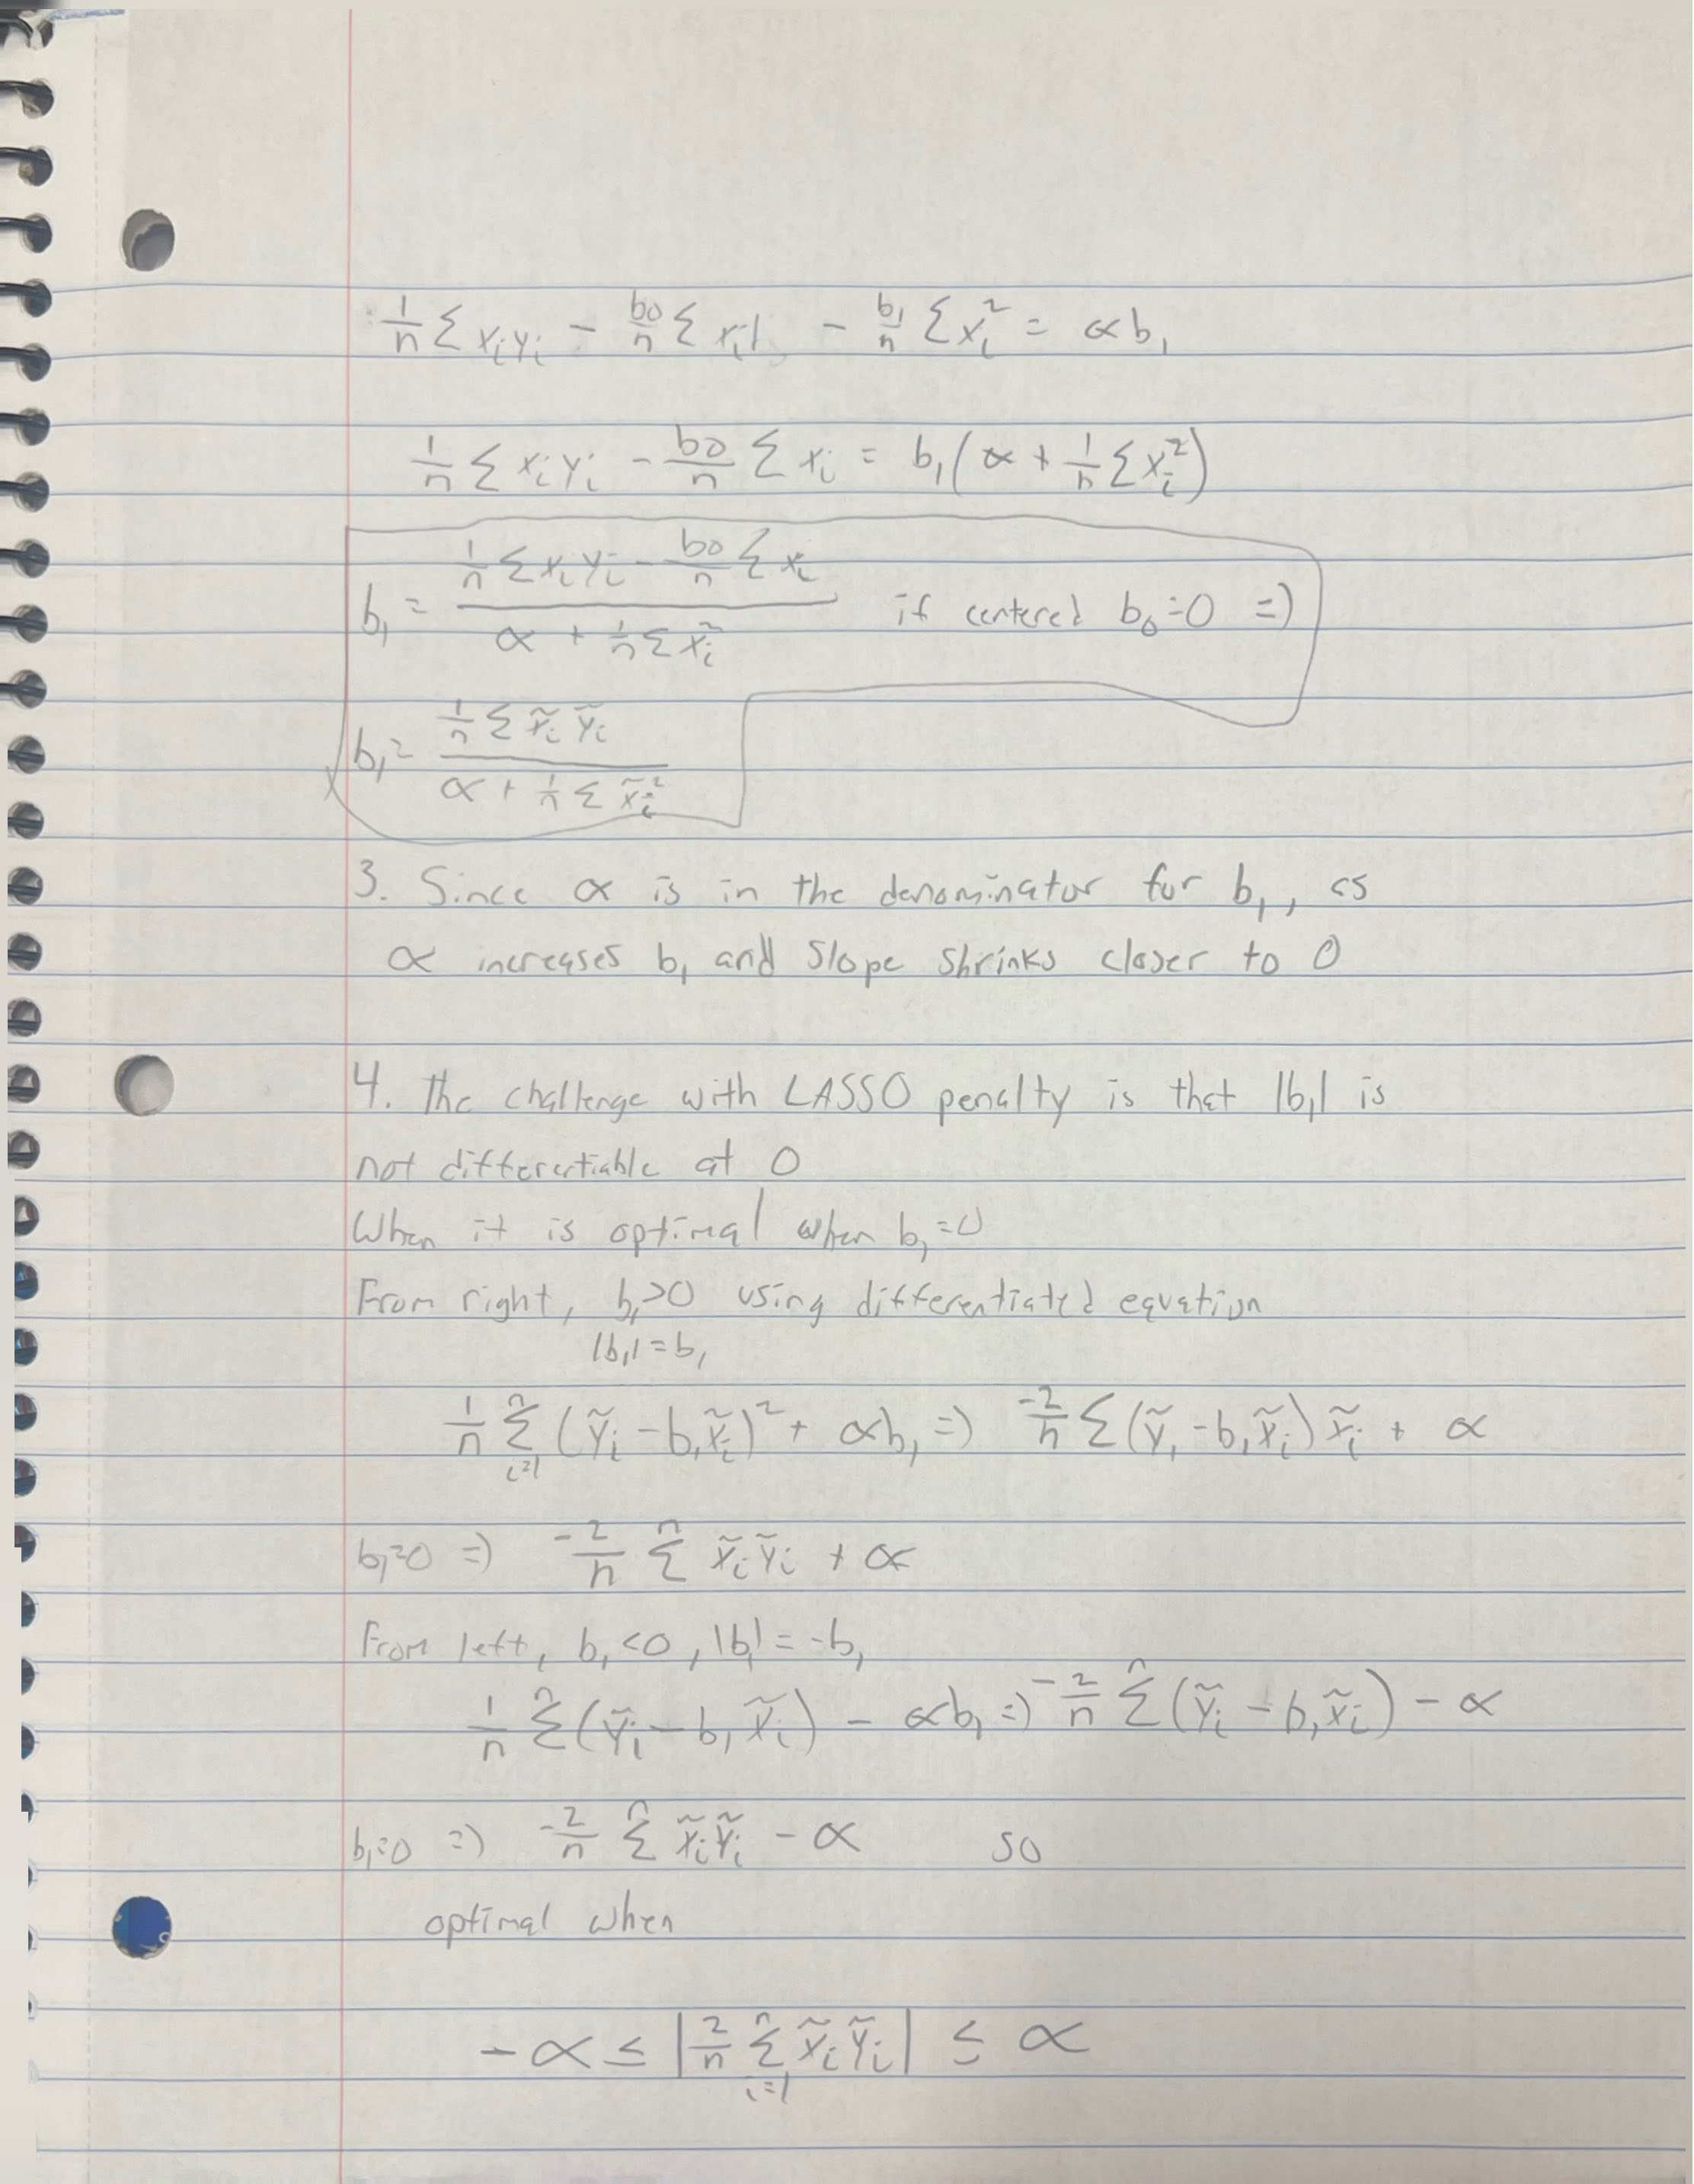